# K-Means Clustering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

[Data Source](https://archive.ics.uci.edu/ml/datasets/Absenteeism+at+work)

In [2]:
df = pd.read_csv("Absenteeism_at_work.csv",delimiter=';')

In [3]:
df.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,239.554,...,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,239.554,...,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,239.554,...,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,239.554,...,0,1,2,1,0,1,90,172,30,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               740 non-null    int64  
 1   Reason for absence               740 non-null    int64  
 2   Month of absence                 740 non-null    int64  
 3   Day of the week                  740 non-null    int64  
 4   Seasons                          740 non-null    int64  
 5   Transportation expense           740 non-null    int64  
 6   Distance from Residence to Work  740 non-null    int64  
 7   Service time                     740 non-null    int64  
 8   Age                              740 non-null    int64  
 9   Work load Average/day            740 non-null    float64
 10  Hit target                       740 non-null    int64  
 11  Disciplinary failure             740 non-null    int64  
 12  Education             

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               740 non-null    int64  
 1   Reason for absence               740 non-null    int64  
 2   Month of absence                 740 non-null    int64  
 3   Day of the week                  740 non-null    int64  
 4   Seasons                          740 non-null    int64  
 5   Transportation expense           740 non-null    int64  
 6   Distance from Residence to Work  740 non-null    int64  
 7   Service time                     740 non-null    int64  
 8   Age                              740 non-null    int64  
 9   Work load Average/day            740 non-null    float64
 10  Hit target                       740 non-null    int64  
 11  Disciplinary failure             740 non-null    int64  
 12  Education             

In [6]:
df.drop('ID',axis=1,inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Reason for absence               740 non-null    int64  
 1   Month of absence                 740 non-null    int64  
 2   Day of the week                  740 non-null    int64  
 3   Seasons                          740 non-null    int64  
 4   Transportation expense           740 non-null    int64  
 5   Distance from Residence to Work  740 non-null    int64  
 6   Service time                     740 non-null    int64  
 7   Age                              740 non-null    int64  
 8   Work load Average/day            740 non-null    float64
 9   Hit target                       740 non-null    int64  
 10  Disciplinary failure             740 non-null    int64  
 11  Education                        740 non-null    int64  
 12  Son                   

# Principal Component Analysis

Running dimensionality reduction algorithm such as Principal component analysis (PCA) prior to K-Means reduces the effects of the curse of dimensionality. PCA reduces the number of features. This can be done by either removing or combining features.

The new features are referred to as **components**. 

In [8]:
# Import PCA
from sklearn.decomposition import PCA

In [9]:
# Create an instance of PCA
pca = PCA(n_components=10, random_state=42)

In [10]:
# Create a variable called X containing the df transformed using PCA
X = pca.fit_transform(df)

In [11]:
X

array([[ 6.71354234e+01, -3.27484750e+01,  2.96182849e+00, ...,
        -1.00465019e+00,  2.41507703e+00, -2.72227113e-01],
       [-1.05230741e+02, -3.08716703e+01, -1.29138398e+01, ...,
         5.41744814e+00,  8.23703492e-01,  2.03145784e+00],
       [-4.16997283e+01, -3.28566715e+01,  2.20178950e+01, ...,
         8.25552754e-01,  1.14615531e+00,  3.69181792e-01],
       ...,
       [-1.04550527e+02,  7.36578248e-01, -8.97532274e+00, ...,
        -6.10674211e+00,  8.46977946e+00, -1.82135753e+00],
       [ 9.17524078e+00, -3.44052966e-01,  2.93343173e+00, ...,
        -2.49802996e+00,  7.77809158e+00, -3.26474530e+00],
       [-4.13992759e+01, -6.32381104e-02,  1.35410165e+01, ...,
         1.34832128e+01,  3.50680556e-01,  1.16352468e+00]],
      shape=(740, 10))

In [12]:
# Display X


# Scaling

In [13]:
# Create an instance of the standard scaler and fit it to X
scaler = StandardScaler()
X_trans = scaler.fit_transform(X)

# [Implement K-Means Clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans)

In [14]:
# Create an intance of KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

In [15]:
kmeans.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 4,
 'n_init': 10,
 'random_state': 42,
 'tol': 0.0001,
 'verbose': 0}

In [16]:
# Check the parameters of Kmeans


k-means++ initializes the centroids to be  distant from each other, leading to better results than random initialization

In [17]:
kmeans.fit_transform(X_trans)

array([[2.7681103 , 1.91726861, 2.73167267, 2.43584015],
       [4.27086527, 4.31461648, 4.15500781, 3.54924679],
       [2.82724944, 2.86163165, 2.8512959 , 1.21590137],
       ...,
       [3.8724107 , 4.66413004, 4.8921048 , 3.80860716],
       [4.18145612, 4.06003019, 4.40870411, 3.42230019],
       [5.12441309, 4.99960902, 4.06913506, 4.16837557]], shape=(740, 4))

In [18]:
#Fit kmeans to X 


Inertia measures how internally coherent clusters are

In [19]:
kmeans.inertia_

5739.12677242771

In [20]:
# Check the inertia


In [21]:
kmeans.cluster_centers_

array([[-0.51899737,  0.07386395, -0.25201668, -0.87890888, -0.08227893,
         0.13427216, -0.19961662, -0.76362196,  0.29163504,  0.00615986],
       [ 0.61129224,  0.00872929, -0.36607972,  0.49226962, -0.10935007,
         0.30145316, -1.43354019,  0.35182425, -0.13631227,  0.10313796],
       [ 0.69180221,  0.05482292, -0.10517831, -0.39556378,  0.13428169,
        -0.1539816 ,  0.947788  ,  0.59345644, -0.25402999,  0.02295999],
       [-0.64411696, -0.15874532,  0.71088446,  1.12858741,  0.03102521,
        -0.22145252,  0.27662724, -0.03336103,  0.04562401, -0.11439465]])

In [22]:
# check the centroids


In [23]:
kmeans.n_iter_

14

In [24]:
# check the number of iterations


In [25]:
# Check the labels
kmeans.labels_

array([1, 3, 3, 2, 1, 3, 1, 2, 1, 0, 2, 2, 2, 3, 3, 2, 3, 3, 0, 2, 1, 3,
       1, 2, 1, 1, 1, 1, 1, 3, 3, 3, 0, 3, 3, 1, 1, 2, 2, 2, 0, 0, 3, 3,
       1, 0, 3, 2, 2, 2, 2, 0, 0, 0, 1, 3, 0, 3, 2, 2, 3, 2, 3, 0, 3, 0,
       3, 0, 0, 0, 2, 2, 3, 0, 2, 2, 0, 1, 1, 2, 3, 0, 3, 2, 2, 1, 0, 2,
       0, 1, 0, 2, 0, 2, 2, 0, 1, 2, 2, 0, 3, 0, 0, 2, 0, 1, 0, 2, 0, 1,
       0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 2, 3, 1, 0, 2, 1, 2, 2, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 1, 2, 2, 0, 2, 3, 0, 0,
       0, 0, 0, 3, 2, 0, 2, 0, 2, 0, 1, 2, 1, 0, 2, 3, 3, 2, 2, 2, 2, 2,
       1, 1, 2, 1, 0, 3, 1, 1, 1, 3, 0, 0, 1, 3, 1, 2, 1, 2, 2, 3, 3, 1,
       2, 1, 2, 2, 2, 3, 1, 2, 3, 0, 3, 3, 2, 3, 3, 0, 1, 3, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 3, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 0, 3,
       2, 0, 3, 0, 1, 0, 3, 3, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 3,
       2, 2, 3, 1, 0, 1, 1, 3, 2, 0, 0, 2, 3, 0, 3,

# Finding the best number of clusters

In [26]:
# Check the optimal number of clusters in a for loop
models = []
for i in range(1, 13):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit_transform(X_trans)
    models.append(model)

In [27]:
# Store the errors in a dataframe

errors_df = pd.DataFrame(data={'N_clusters': [model.n_clusters for model in models], 
                               'Inertia': [model.inertia_ for model in models]})
errors_df

,N_clusters,Inertia
0,1,7400.000000
1,2,6763.456157
2,3,6236.511258
3,4,5739.126772
4,5,5240.599135
5,6,4913.697736
6,7,4475.717460
7,8,4270.138359
8,9,4050.004758
9,10,3866.969472


(0.0, 8000.0)

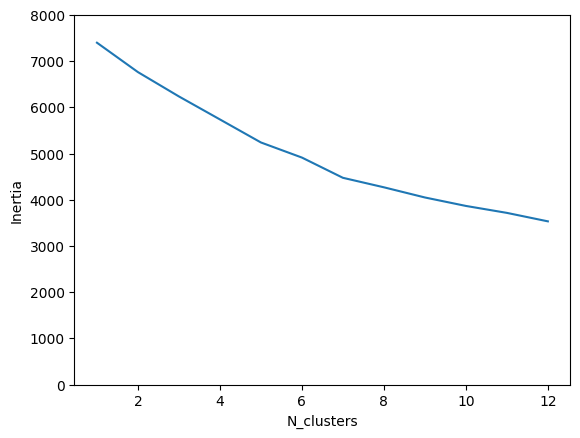

In [28]:
# Plot the errors
g = sns.lineplot(data=errors_df, x='N_clusters', y='Inertia')
g.set_ylim(0, 8000)

In [41]:
# Use the kneeLocator to get the optimal number of clusters
kneedle = KneeLocator(range(1,13), [model.inertia_ for model in models], S=1.0, curve="convex", direction="decreasing")

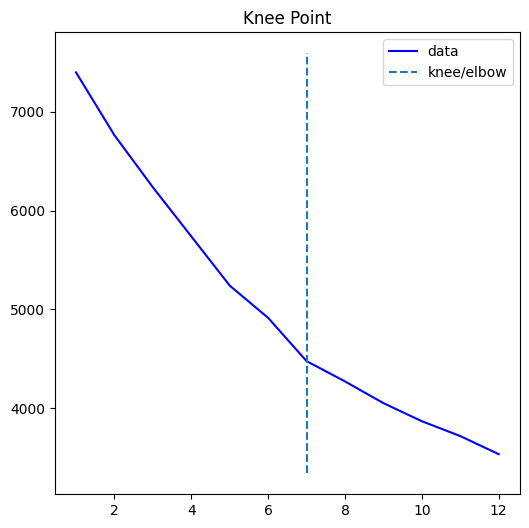

In [42]:
# check the optimal number of clusters
kneedle.plot_knee()

In [44]:
kneedle.elbow

np.int64(7)

In [45]:
# Create KMeans again using the optimal number of clusters
kmeans = KMeans(n_clusters=kneedle.elbow, random_state=42, n_init=10)
predictions = kmeans.fit_predict(X_trans)

In [33]:
# Add the clusters to the initial dataframe
df['clusters'] = predictions

In [34]:
# Check the tail of the dataframe
df.tail()

,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,Hit target,...,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours,clusters
735,14,7,3,1,289,36,13,33,264.604,93,...,1,2,1,0,1,90,172,30,8,5
736,11,7,3,1,235,11,14,37,264.604,93,...,3,1,0,0,1,88,172,29,4,4
737,0,0,3,1,118,14,13,40,271.219,95,...,1,1,1,0,8,98,170,34,0,4
738,0,0,4,2,231,35,14,39,271.219,95,...,1,2,1,0,2,100,170,35,0,2
739,0,0,6,3,179,45,14,53,271.219,95,...,1,1,0,0,1,77,175,25,0,0


In [35]:
# Select the clusters in cluster 0 and save them as a csv
cluster_zero = df[df.clusters == 0]
cluster_zero.to_csv('cluster_zero.csv', index=False)

In [36]:
# PPrint the head of cluster zero
cluster_zero.head()

,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,Hit target,...,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours,clusters
3,7,7,5,1,279,5,14,39,239.554,97,...,1,2,1,1,0,68,168,24,4,0
7,23,7,6,1,260,50,11,36,239.554,97,...,1,4,1,0,0,65,168,23,4,0
10,1,7,2,1,260,50,11,36,239.554,97,...,1,4,1,0,0,65,168,23,8,0
11,1,7,3,1,260,50,11,36,239.554,97,...,1,4,1,0,0,65,168,23,8,0
12,11,7,4,1,260,50,11,36,239.554,97,...,1,4,1,0,0,65,168,23,8,0


<Axes: xlabel='clusters', ylabel='count'>

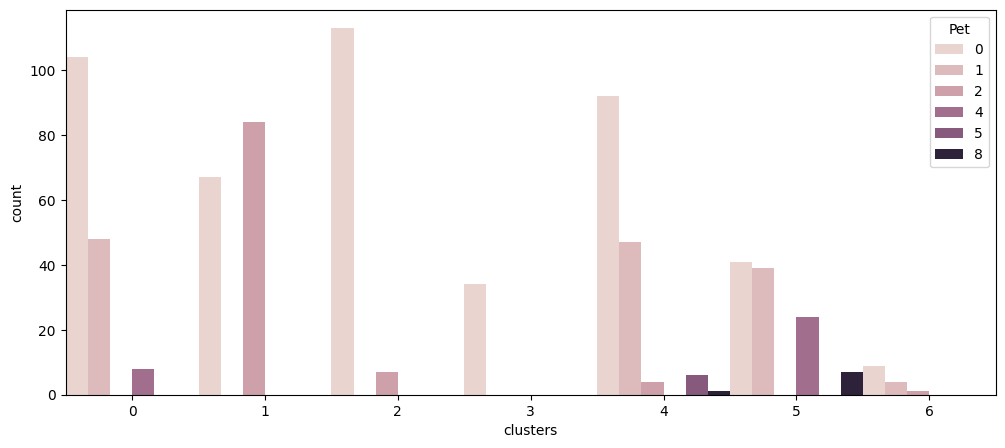

In [37]:
# Plot a countplot of the clusters with Pet as the Hue
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='clusters', hue='Pet', width=1,)

<Axes: xlabel='Work load Average/day ', ylabel='Transportation expense'>

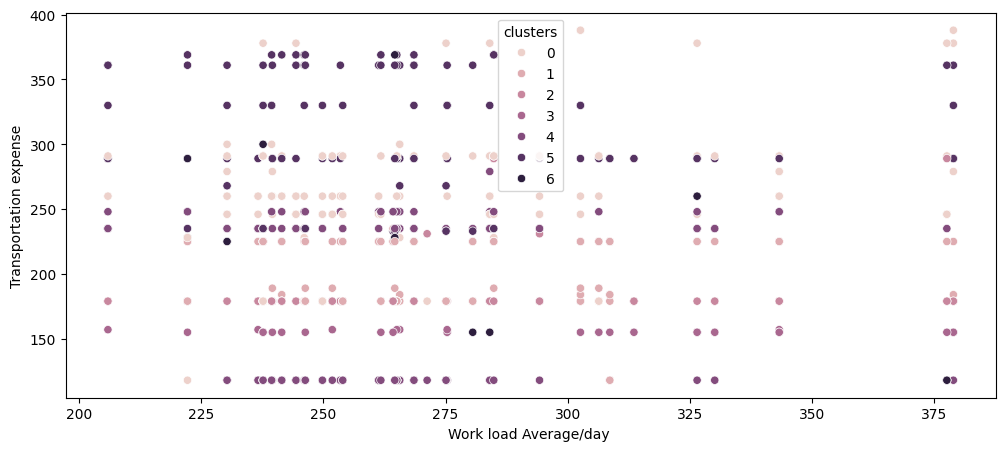

In [38]:
# Plot a scatter plot of the Work load Average/day and the Transportation expense
# with Hue as the cluster
plt.figure(figsize=(12, 5))
sns.scatterplot(data = df, x = 'Work load Average/day ', y = 'Transportation expense', hue='clusters')

Happy Clustering!

# 